# Análise de Erros — TREC 2007

Análise detalhada dos erros de classificação dos quatro modelos treinados sobre o corpus TREC 2007 com truncagem em 150 palavras. Investiga-se:

- **Resumo quantitativo** de VP, VN, FP e FN por modelo;
- **Exemplos concretos** de falsos positivos e falsos negativos;
- **Padrões de comprimento** dos e-mails classificados correta e incorretamente;
- **Erros comuns** a todos os modelos vs. erros exclusivos;
- **Sobreposição de erros** entre pares de modelos (heatmap).

In [1]:
import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# ── Caminhos ──────────────────────────────────────────────
BASE_DIR     = Path().resolve().parent.parent
DATA_DIR     = BASE_DIR / 'data'
MODELS_DIR   = BASE_DIR / 'models'
TREC_DIR     = MODELS_DIR / 'trec'
FIGURES_DIR  = BASE_DIR / 'figures'
CONCL_FIG    = FIGURES_DIR / 'conclusions'
CONCL_FIG.mkdir(parents=True, exist_ok=True)

# ── Paleta de cores ───────────────────────────────────────
NAVY   = '#1C2B4A'
TEAL   = '#0891B2'
RED    = '#DC2626'
ORANGE = '#F59E0B'
GRAY   = '#64748B'

# ── Estilo global dos gráficos ────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titleweight': 'bold',
})

print(f'Projeto em       : {BASE_DIR}')
print(f'Figuras salvas em: {CONCL_FIG}')

/tmp/ipykernel_17001/2936863942.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Projeto em       : /home/edson-luiz/Projetos/TCC
Figuras salvas em: /home/edson-luiz/Projetos/TCC/figures/conclusions


In [2]:
# ── Carregar modelos, dados de teste e vetorizador TF-IDF ──

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

MODEL_FILES = {
    'Naive Bayes':         'model_naive_bayes.pkl',
    'SVM':                 'model_svm.pkl',
    'Random Forest':       'model_random_forest.pkl',
    'Regressão Logística': 'model_regressao_logística.pkl',
}

models = {name: load_pkl(TREC_DIR / fname) for name, fname in MODEL_FILES.items()}
X_test_tfidf = load_pkl(TREC_DIR / 'X_test_tfidf.pkl')
y_test       = load_pkl(TREC_DIR / 'y_test.pkl')
tfidf        = load_pkl(TREC_DIR / 'tfidf.pkl')

print(f'Modelos carregados : {list(models.keys())}')
print(f'X_test shape       : {X_test_tfidf.shape}')
print(f'y_test shape       : {y_test.shape}')

# ── Recarregar CSV e refazer pré-processamento para obter textos originais ──

STOP_WORDS = set(stopwords.words('english'))

def truncate_to_150_words(text):
    words = str(text).split()
    return ' '.join(words[:150])

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

def full_preprocess(text):
    return preprocess(truncate_to_150_words(text))

# Carregar CSV raw
df_raw = pd.read_csv(DATA_DIR / 'trec_2007.csv', encoding='latin-1', on_bad_lines='skip')

# Auto-detectar colunas (mesma lógica do notebook de pré-processamento)
TEXT_CANDIDATES  = ['body', 'message', 'text', 'email', 'content', 'mail']
LABEL_CANDIDATES = ['label', 'spam', 'class', 'category', 'spam/ham', 'type', 'tag']
cols_lower = {c.lower(): c for c in df_raw.columns}

text_col  = next((cols_lower[c] for c in TEXT_CANDIDATES  if c in cols_lower), None)
label_col = next((cols_lower[c] for c in LABEL_CANDIDATES if c in cols_lower), None)

if text_col is None:
    str_cols = df_raw.select_dtypes(include='object').columns.tolist()
    text_col = max(str_cols, key=lambda c: df_raw[c].str.len().mean())
if label_col is None:
    str_cols = df_raw.select_dtypes(include='object').columns.tolist()
    label_col = min([c for c in str_cols if c != text_col],
                    key=lambda c: df_raw[c].nunique())

print(f'\nColuna de texto  : "{text_col}"')
print(f'Coluna de rótulo : "{label_col}"')

# Pré-processar
df = df_raw[[text_col, label_col]].copy()
df = df.dropna(subset=[text_col])
df['text_truncated'] = df[text_col].apply(truncate_to_150_words)
df['text_processed'] = df[text_col].apply(full_preprocess)
df = df[df['text_processed'].str.strip() != '']

# Mapear rótulos
valores_unicos = df[label_col].dropna().unique()
label_map = {}
for v in valores_unicos:
    v_lower = str(v).strip().lower()
    if v_lower in ('spam', '1', 'yes', 'true', 's'):
        label_map[v] = 1
    elif v_lower in ('ham', '0', 'no', 'false', 'h', 'legitimate'):
        label_map[v] = 0
if len(label_map) != len(valores_unicos):
    sorted_vals = sorted([str(v) for v in valores_unicos])
    label_map = {v: i for i, v in enumerate(sorted_vals)}

df['label'] = df[label_col].map(label_map)
df = df[df['label'].notna()]
df['label'] = df['label'].astype(int)

# Mesmo split para alinhar índices
X_all = df['text_processed']
y_all = df['label']

_, X_test_text, _, _ = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)

# Recuperar textos originais (truncados) alinhados pelo índice
test_indices = X_test_text.index
df_test = df.loc[test_indices].copy().reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True) if hasattr(y_test, 'reset_index') else pd.Series(y_test)

# Adicionar contagem de palavras
df_test['n_words'] = df_test['text_processed'].str.split().str.len()

print(f'\nE-mails de teste recuperados: {len(df_test)}')
print(f'Distribuição: ham={int((df_test["label"]==0).sum())}, spam={int((df_test["label"]==1).sum())}')

Modelos carregados : ['Naive Bayes', 'SVM', 'Random Forest', 'Regressão Logística']
X_test shape       : (14755, 10000)
y_test shape       : (14755,)



Coluna de texto  : "message"
Coluna de rótulo : "label"



E-mails de teste recuperados: 14755
Distribuição: ham=5044, spam=9711


In [3]:
# ── Tabela resumo de erros: VP, VN, FP, FN por modelo ─────────────────────

summary_rows = []
preds = {}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    preds[name] = y_pred

    cm = confusion_matrix(y_test_reset, y_pred)
    tn, fp, fn, tp = cm.ravel()

    summary_rows.append({
        'Modelo':              name,
        'VP (spam→spam)':      tp,
        'VN (ham→ham)':        tn,
        'FP (ham→spam)':       fp,
        'FN (spam→ham)':       fn,
        'Total de erros':      fp + fn,
        'Taxa de erro (%)':    round((fp + fn) / len(y_test_reset) * 100, 2),
    })

    # Salvar flags de erro no df_test
    df_test[f'pred_{name}']  = y_pred
    df_test[f'erro_{name}']  = (y_pred != y_test_reset.values).astype(int)
    df_test[f'fp_{name}']    = ((y_pred == 1) & (y_test_reset.values == 0)).astype(int)
    df_test[f'fn_{name}']    = ((y_pred == 0) & (y_test_reset.values == 1)).astype(int)

df_summary = pd.DataFrame(summary_rows).set_index('Modelo')
df_summary = df_summary.sort_values('Total de erros', ascending=True)

print('=' * 75)
print('RESUMO DE ERROS POR MODELO — TREC 2007 (150 palavras)')
print('=' * 75)

styled = df_summary.style \
    .background_gradient(subset=['Total de erros'], cmap='Reds') \
    .format({'Taxa de erro (%)': '{:.2f}%'})
styled

RESUMO DE ERROS POR MODELO — TREC 2007 (150 palavras)


,VP (spam→spam),VN (ham→ham),FP (ham→spam),FN (spam→ham),Total de erros,Taxa de erro (%)
Modelo,,,,,,
Random Forest,9674,4978,66,37,103,0.70%
SVM,9669,4978,66,42,108,0.73%
Regressão Logística,9663,4935,109,48,157,1.06%
Naive Bayes,9061,4997,47,650,697,4.72%


In [4]:
# ── Exemplos de FP e FN do Naive Bayes (modelo com mais erros) ─────────────

NB = 'Naive Bayes'
DISPLAY_LEN = 200  # caracteres para exibição

fp_nb = df_test[df_test[f'fp_{NB}'] == 1].copy()
fn_nb = df_test[df_test[f'fn_{NB}'] == 1].copy()

print(f'Naive Bayes — Falsos Positivos: {len(fp_nb)}  |  Falsos Negativos: {len(fn_nb)}')

print(f'\n{"=" * 80}')
print(f'  5 EXEMPLOS DE FALSOS POSITIVOS (ham classificado como spam)')
print(f'{"=" * 80}')
for i, (_, row) in enumerate(fp_nb.head(5).iterrows()):
    texto = str(row['text_truncated'])[:DISPLAY_LEN]
    print(f'\n  [{i+1}] Rótulo real: HAM  |  Predição: SPAM  |  Palavras: {row["n_words"]}')
    print(f'      "{texto}..."')

print(f'\n{"=" * 80}')
print(f'  5 EXEMPLOS DE FALSOS NEGATIVOS (spam classificado como ham)')
print(f'{"=" * 80}')
for i, (_, row) in enumerate(fn_nb.head(5).iterrows()):
    texto = str(row['text_truncated'])[:DISPLAY_LEN]
    print(f'\n  [{i+1}] Rótulo real: SPAM  |  Predição: HAM  |  Palavras: {row["n_words"]}')
    print(f'      "{texto}..."')

Naive Bayes — Falsos Positivos: 47  |  Falsos Negativos: 650

  5 EXEMPLOS DE FALSOS POSITIVOS (ham classificado como spam)

  [1] Rótulo real: HAM  |  Predição: SPAM  |  Palavras: 4
      "hi jessica, this should possibly do it... year..."

  [2] Rótulo real: HAM  |  Predição: SPAM  |  Palavras: 18
      "Formula that is proven to increase your SPERM by 500%. WonderCum has been developed to give you, the consumer, the ultimate semen enhancement product. http://btrobot.com ______________________________..."

  [3] Rótulo real: HAM  |  Predição: SPAM  |  Palavras: 89
      "Content-Type: text/plain; charset="us-ascii" Content-Transfer-Encoding: 7bit howstuffworks(r)| lifestyle May 24, 2007 http://www.howstuffworks.com/rss-feeds.htm RSS http://entertainment.howstuffworks...."

  [4] Rótulo real: HAM  |  Predição: SPAM  |  Palavras: 145
      "Content-Type: multipart/alternative; boundary="=====================_2874406==.ALT" --=====================_2874406==.ALT Content-Type: text/plain;

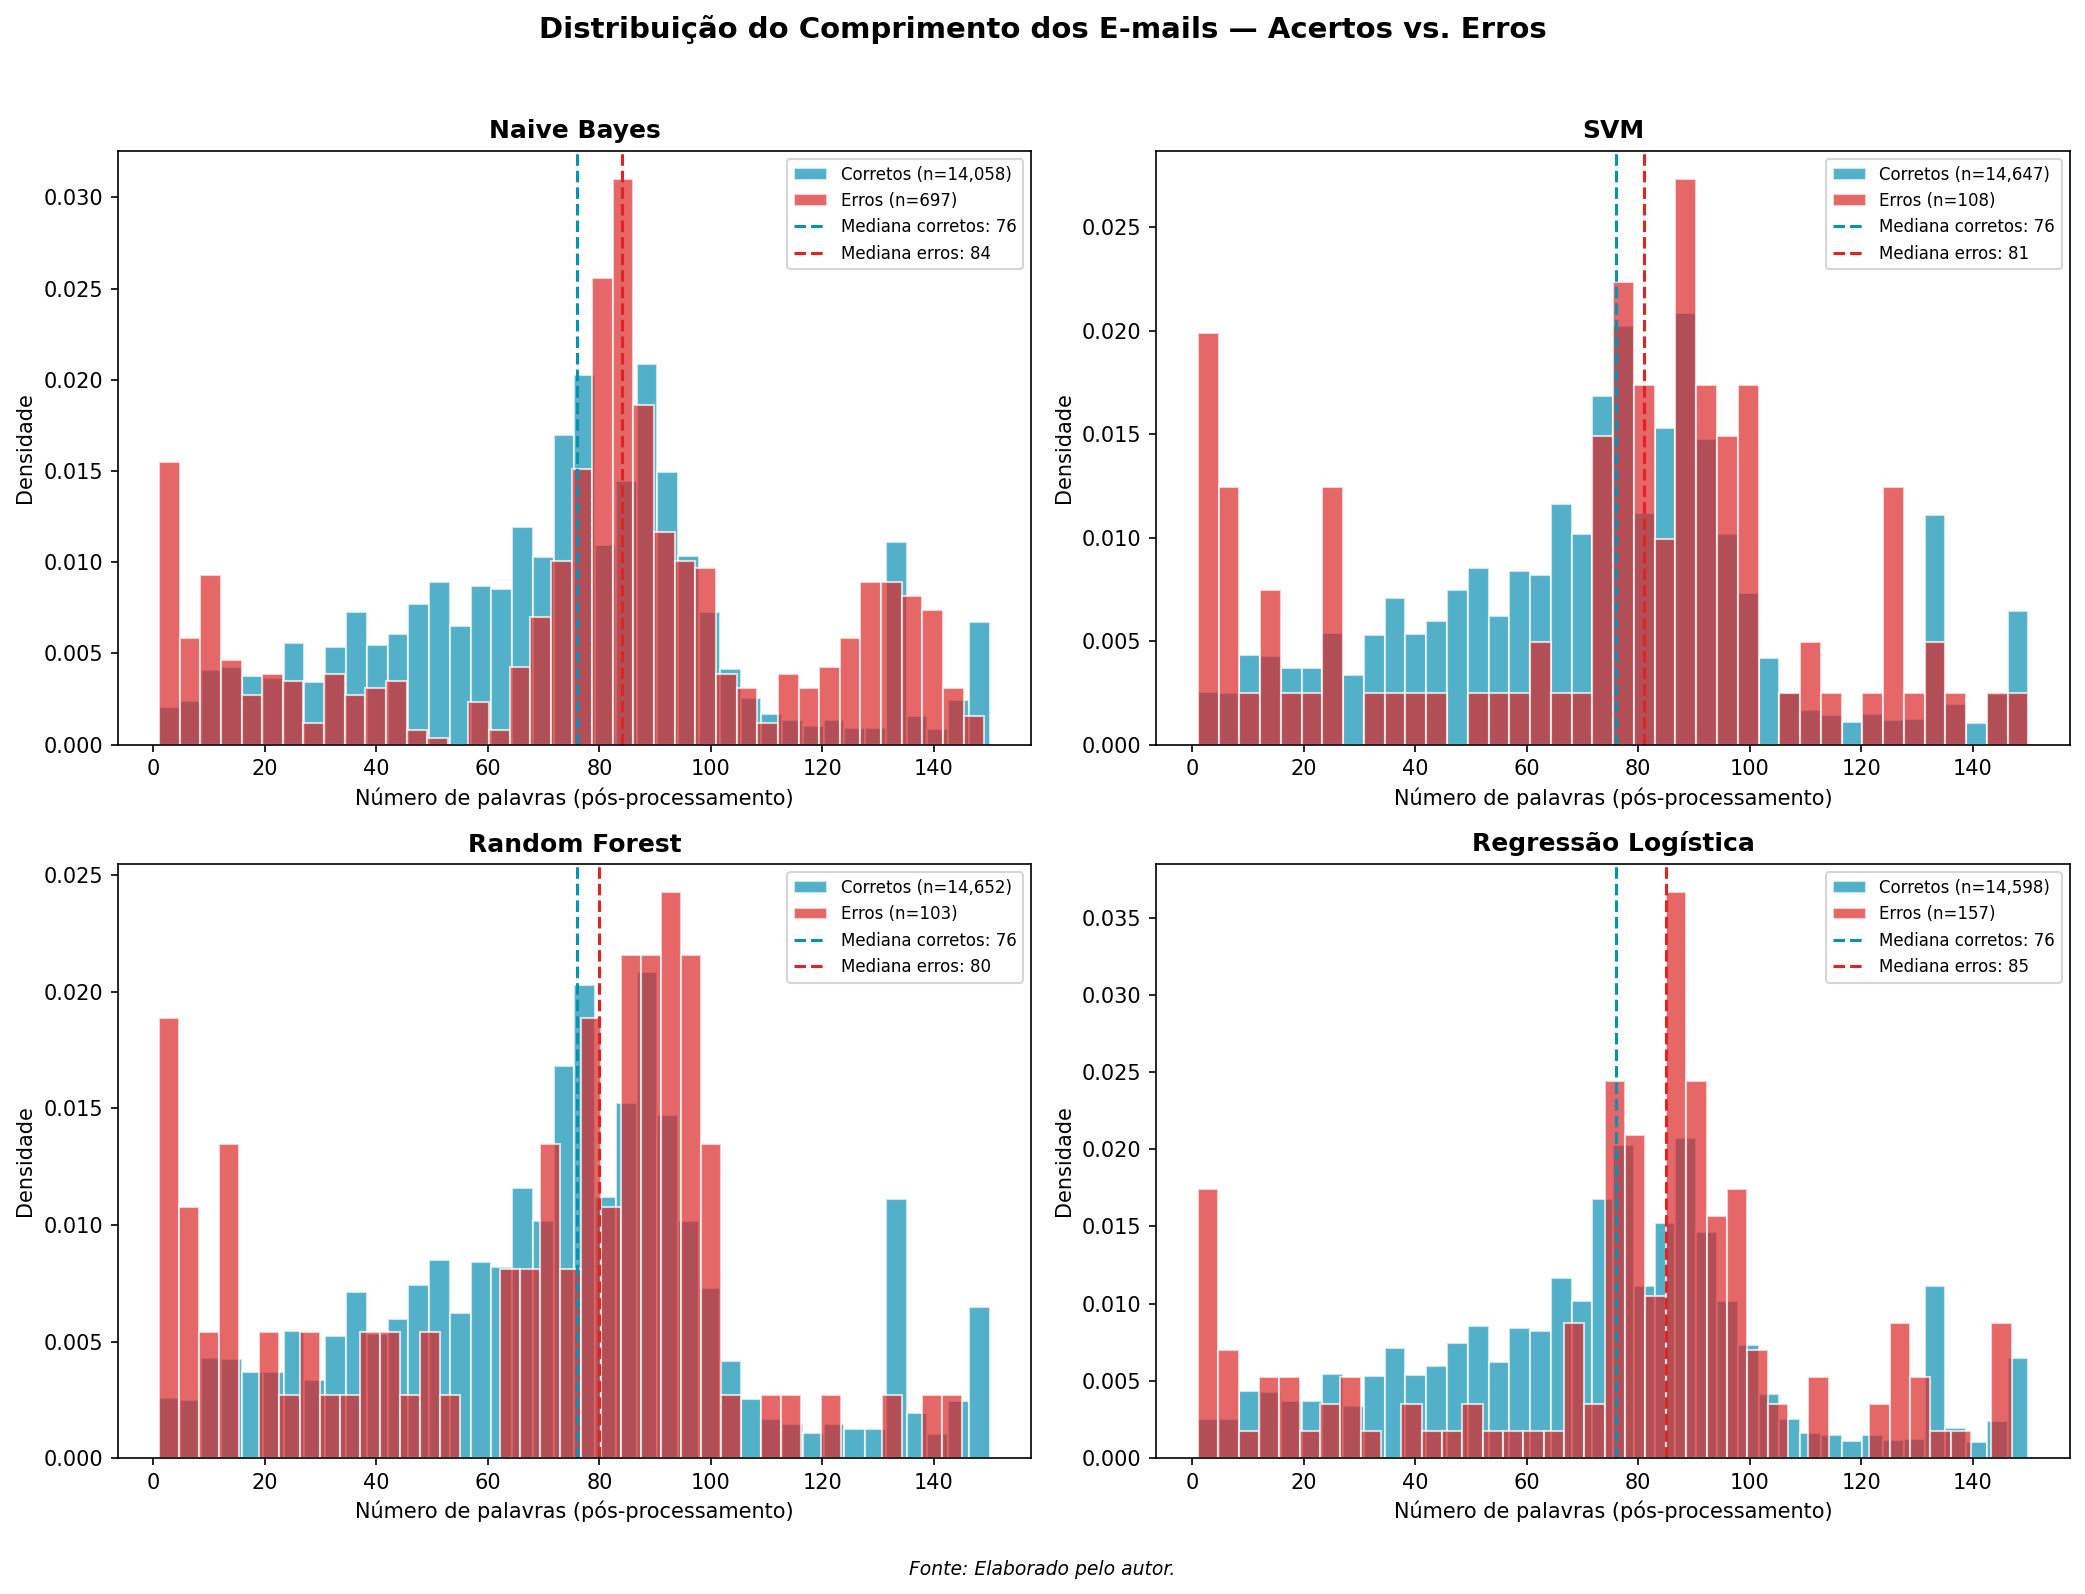

Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/error_word_count_distribution.png


In [5]:
# ── Padrão de comprimento: e-mails corretos vs. incorretos ────────────────

model_names = list(models.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Distribuição do Comprimento dos E-mails — Acertos vs. Erros',
    fontsize=14, fontweight='bold', y=1.02,
)

for ax, name in zip(axes.ravel(), model_names):
    corretos = df_test[df_test[f'erro_{name}'] == 0]['n_words']
    errados  = df_test[df_test[f'erro_{name}'] == 1]['n_words']

    ax.hist(corretos, bins=40, alpha=0.7, color=TEAL, label=f'Corretos (n={len(corretos):,})',
            density=True, edgecolor='white')
    ax.hist(errados,  bins=40, alpha=0.7, color=RED,  label=f'Erros (n={len(errados):,})',
            density=True, edgecolor='white')

    ax.axvline(corretos.median(), color=TEAL, linestyle='--', linewidth=1.5,
               label=f'Mediana corretos: {corretos.median():.0f}')
    ax.axvline(errados.median(),  color=RED,  linestyle='--', linewidth=1.5,
               label=f'Mediana erros: {errados.median():.0f}')

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Número de palavras (pós-processamento)')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8, loc='upper right')

fig.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig(CONCL_FIG / 'error_word_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura salva: {CONCL_FIG / "error_word_count_distribution.png"}')

In [6]:
# ── Erros comuns a todos os modelos vs. exclusivos do Naive Bayes ─────────

# Criar máscara de erro por modelo
erro_cols = [f'erro_{name}' for name in model_names]

df_test['erros_total'] = df_test[erro_cols].sum(axis=1)
df_test['erro_todos']  = (df_test['erros_total'] == len(model_names)).astype(int)

# E-mails errados por TODOS os 4 modelos
erros_todos = df_test[df_test['erro_todos'] == 1]

# E-mails errados APENAS pelo Naive Bayes
df_test['erro_apenas_nb'] = (
    (df_test[f'erro_{NB}'] == 1) &
    (df_test[[f'erro_{n}' for n in model_names if n != NB]].sum(axis=1) == 0)
).astype(int)
erros_apenas_nb = df_test[df_test['erro_apenas_nb'] == 1]

print('=' * 75)
print('ANÁLISE DE ERROS COMUNS E EXCLUSIVOS')
print('=' * 75)

print(f'\nE-mails classificados INCORRETAMENTE por TODOS os 4 modelos: {len(erros_todos)}')
if len(erros_todos) > 0:
    n_fp_todos = ((erros_todos['label'] == 0)).sum()
    n_fn_todos = ((erros_todos['label'] == 1)).sum()
    print(f'  Destes: {n_fp_todos} são FP (ham→spam) e {n_fn_todos} são FN (spam→ham)')
    print(f'\n  Exemplos de erros universais (difíceis para todos os modelos):')
    for i, (_, row) in enumerate(erros_todos.head(5).iterrows()):
        tipo = 'FP' if row['label'] == 0 else 'FN'
        texto = str(row['text_truncated'])[:150]
        print(f'    [{i+1}] {tipo} | Palavras: {row["n_words"]} | "{texto}..."')

print(f'\nE-mails classificados INCORRETAMENTE APENAS pelo Naive Bayes: {len(erros_apenas_nb)}')
if len(erros_apenas_nb) > 0:
    n_fp_nb = ((erros_apenas_nb['label'] == 0)).sum()
    n_fn_nb = ((erros_apenas_nb['label'] == 1)).sum()
    print(f'  Destes: {n_fp_nb} são FP (ham→spam) e {n_fn_nb} são FN (spam→ham)')
    print(f'\n  Exemplos de erros exclusivos do Naive Bayes:')
    for i, (_, row) in enumerate(erros_apenas_nb.head(5).iterrows()):
        tipo = 'FP' if row['label'] == 0 else 'FN'
        texto = str(row['text_truncated'])[:150]
        print(f'    [{i+1}] {tipo} | Palavras: {row["n_words"]} | "{texto}..."')

# Distribuição: quantos modelos erram cada e-mail?
print(f'\n{"=" * 75}')
print('Distribuição: por quantos modelos cada e-mail de teste é classificado incorretamente')
print('=' * 75)
dist_erros = df_test['erros_total'].value_counts().sort_index()
for n_modelos, count in dist_erros.items():
    barra = '█' * (count // max(1, dist_erros.max() // 40))
    print(f'  {n_modelos} modelo(s): {count:>5,} e-mails  {barra}')

ANÁLISE DE ERROS COMUNS E EXCLUSIVOS

E-mails classificados INCORRETAMENTE por TODOS os 4 modelos: 28
  Destes: 19 são FP (ham→spam) e 9 são FN (spam→ham)

  Exemplos de erros universais (difíceis para todos os modelos):
    [1] FN | Palavras: 72 | "June 19, 2007 âMarket Checkupâ Iâve told you before, and Iâm going to tell you again: the market may look like a happy, healthy person in thei..."
    [2] FP | Palavras: 145 | "Content-Type: multipart/alternative; boundary="=====================_2874406==.ALT" --=====================_2874406==.ALT Content-Type: text/plain; ch..."
    [3] FN | Palavras: 93 | "Word Is Out, Big News Monday! Score One Inc. SREA $0.20 UP 33.3% This week's news has already been pushing SREA up. Word is out a BIG news release is ..."
    [4] FN | Palavras: 72 | "April 11, 2007 âThe Big Pictureâ It was a wacky, crazy day for Trending123 folks.Â At least it seemed that way to me after spending time in our tr..."
    [5] FP | Palavras: 76 | "Content-Type:

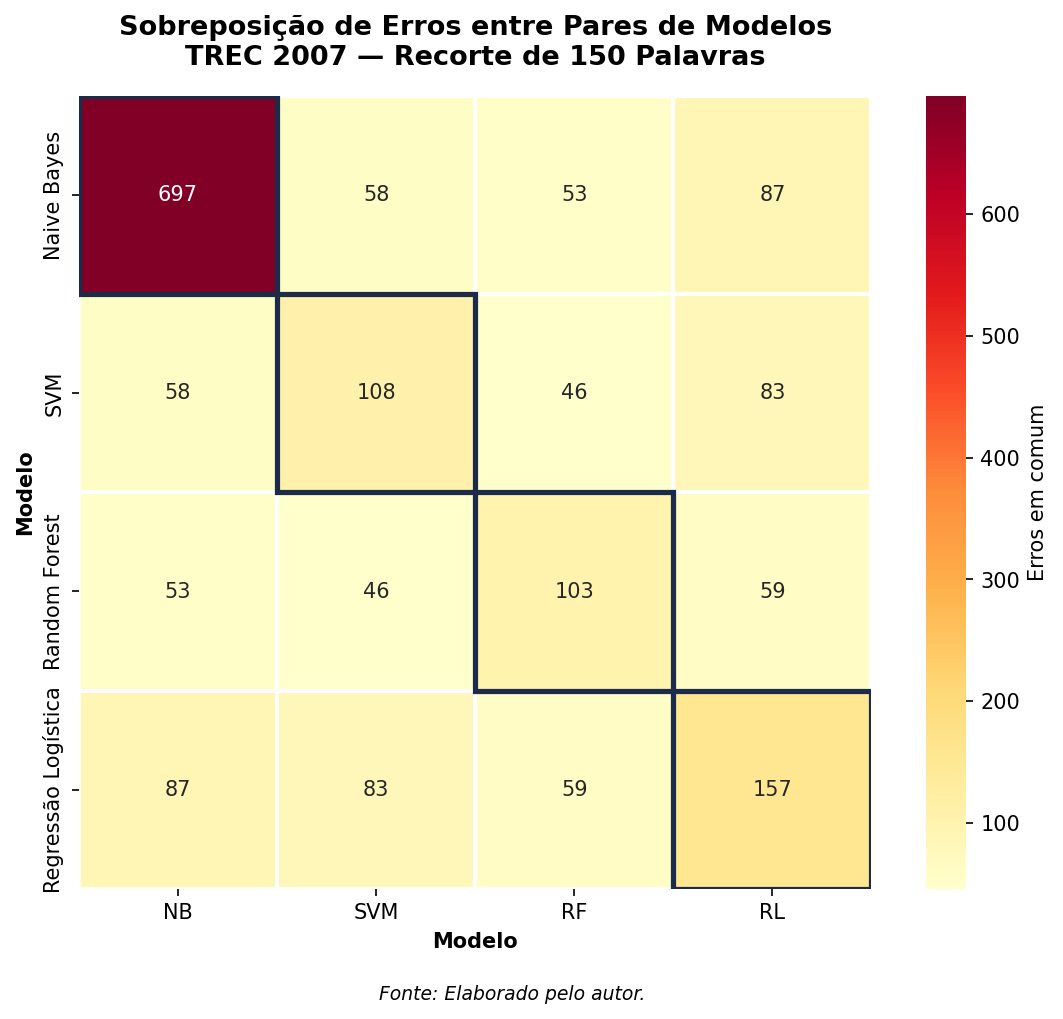

Diagonal = total de erros do próprio modelo.
Fora da diagonal = erros compartilhados entre dois modelos.

Figura salva: /home/edson-luiz/Projetos/TCC/figures/conclusions/error_overlap_heatmap.png


In [7]:
# ── Heatmap de sobreposição de erros entre pares de modelos ───────────────

n_models = len(model_names)
overlap_matrix = np.zeros((n_models, n_models), dtype=int)

for i, name_i in enumerate(model_names):
    erros_i = set(df_test[df_test[f'erro_{name_i}'] == 1].index)
    for j, name_j in enumerate(model_names):
        erros_j = set(df_test[df_test[f'erro_{name_j}'] == 1].index)
        overlap_matrix[i, j] = len(erros_i & erros_j)

df_overlap = pd.DataFrame(
    overlap_matrix,
    index=model_names,
    columns=model_names,
)

# Nomes abreviados para melhor visualização
short_names = ['NB', 'SVM', 'RF', 'RL']

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.zeros_like(overlap_matrix, dtype=bool)

sns.heatmap(
    df_overlap,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=1,
    linecolor='white',
    ax=ax,
    xticklabels=short_names,
    yticklabels=model_names,
    cbar_kws={'label': 'Erros em comum'},
    square=True,
)

ax.set_title(
    'Sobreposição de Erros entre Pares de Modelos\nTREC 2007 — Recorte de 150 Palavras',
    fontsize=13, fontweight='bold', pad=15,
)
ax.set_xlabel('Modelo', fontweight='bold')
ax.set_ylabel('Modelo', fontweight='bold')

# Diagonal = total de erros do modelo
for i in range(n_models):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor=NAVY, linewidth=2.5))

fig.text(0.5, -0.03, 'Fonte: Elaborado pelo autor.', ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig(CONCL_FIG / 'error_overlap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Diagonal = total de erros do próprio modelo.')
print('Fora da diagonal = erros compartilhados entre dois modelos.')
print(f'\nFigura salva: {CONCL_FIG / "error_overlap_heatmap.png"}')

In [8]:
# ── Salvar todas as figuras (confirmação) ─────────────────────────────────

figuras_salvas = list(CONCL_FIG.glob('error_*.png'))

print('=' * 60)
print('FIGURAS SALVAS — ANÁLISE DE ERROS')
print('=' * 60)
for fig_path in sorted(figuras_salvas):
    size_kb = fig_path.stat().st_size / 1024
    print(f'  {fig_path.name:<45} ({size_kb:.0f} KB)')
print('=' * 60)
print(f'\nTotal: {len(figuras_salvas)} figuras em {CONCL_FIG}')

FIGURAS SALVAS — ANÁLISE DE ERROS
  error_overlap_heatmap.png                     (182 KB)
  error_word_count_distribution.png             (402 KB)

Total: 2 figuras em /home/edson-luiz/Projetos/TCC/figures/conclusions
